# FleetPride Branch Retention Analytics
**UT Dallas MSBA Capstone · Spring 2026**

End-to-end customer churn prediction and intervention framework across three branches.
Uses ticket file for transactions and branch attribution, category file for product breadth,
and service file for service engagement features.

**Outputs:** `fleetpride_final_call_list.csv` with churn scores, risk tiers, uplift segments,
revenue at risk, SHAP reason codes, and a recommended action per account.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    log_loss, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve

try:
    from xgboost import XGBClassifier
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier

import shap
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Date windows
CUTOFF       = pd.Timestamp('2025-09-01')   # features computed before this date
CHURN_END    = pd.Timestamp('2026-02-28')   # forward window for label
RECENT_START = pd.Timestamp('2025-03-01')   # last 6 months before cutoff
PRIOR_START  = pd.Timestamp('2024-09-01')   # 6 months before that (for trajectory)
ANNUAL_START = pd.Timestamp('2024-09-01')   # 12 months before cutoff (for RAR)

print(f'Observation window : Jan 2023 – Aug 2025  (32 months)')
print(f'Recent window      : Mar 2025 – Aug 2025  (6 months)')
print(f'Prior window       : Sep 2024 – Feb 2025  (6 months)')
print(f'Churn label window : Sep 2025 – Feb 2026  (forward)')


Observation window : Jan 2023 – Aug 2025  (32 months)
Recent window      : Mar 2025 – Aug 2025  (6 months)
Prior window       : Sep 2024 – Feb 2025  (6 months)
Churn label window : Sep 2025 – Feb 2026  (forward)


## 1. Load Data

In [4]:
import os

DATA_DIR = '.'  

tkt_df = pd.read_csv(os.path.join(DATA_DIR, 'PROJ_TKT_COUNT_MASKED_v2.csv'))
cat_df = pd.read_csv(os.path.join(DATA_DIR, 'PROJ_CATEGORY_MASKED_v1.csv'))
svc_df = pd.read_csv(os.path.join(DATA_DIR, 'PROJ_SVC_MASKED_v1.csv'))

for df in [tkt_df, cat_df, svc_df]:
    df.columns = [c.lower() for c in df.columns]
    df['salesmonth'] = pd.to_datetime(df['salesmonth'])

print(f'Ticket file   : {len(tkt_df):>8,} rows | {tkt_df["custnumber"].nunique():,} customers | branches: {sorted(tkt_df["location"].unique())}')
print(f'Category file : {len(cat_df):>8,} rows | {cat_df["custnumber"].nunique():,} customers | categories: {cat_df["category"].nunique()}')
print(f'Service file  : {len(svc_df):>8,} rows | {svc_df["custnumber"].nunique():,} customers')
print(f'\nNote: category file location is a masking artifact — branch is joined from ticket file.')


Ticket file   :  231,489 rows | 6,170 customers | branches: ['LOC_001', 'LOC_002', 'LOC_003']
Category file :  419,456 rows | 6,170 customers | categories: 465
Service file  :   16,036 rows | 2,275 customers

Note: category file location is a masking artifact — branch is joined from ticket file.


## 2. Data Quality

In [5]:
# Positive-sales working frames only
tkt_pos = tkt_df[tkt_df['sales'] > 0].copy()
cat_pos = cat_df[cat_df['sales'] > 0].copy()
svc_pos = svc_df[svc_df['sales'] > 0].copy()

for name, raw, pos in [('Ticket', tkt_df, tkt_pos), ('Category', cat_df, cat_pos), ('Service', svc_df, svc_pos)]:
    neg  = (raw['sales'] < 0).sum()
    zero = (raw['sales'] == 0).sum()
    print(f'{name:10s}  rows={len(raw):>8,}  pos={len(pos):>8,}  neg={neg:>6,} ({neg/len(raw)*100:.1f}%)  zero={zero:>5,}')

print(f'\nDate range: {tkt_pos["salesmonth"].min().date()} to {tkt_pos["salesmonth"].max().date()}')


Ticket      rows= 231,489  pos= 204,967  neg=17,203 (7.4%)  zero=9,319
Category    rows= 419,456  pos= 372,729  neg=24,329 (5.8%)  zero=22,398
Service     rows=  16,036  pos=  15,240  neg=   697 (4.3%)  zero=   99

Date range: 2023-01-01 to 2026-03-01


## 3. Observation Window & Branch Assignment

In [6]:
# Restrict to observation window
obs_tkt = tkt_pos[tkt_pos['salesmonth'] < CUTOFF].copy()
obs_cat = cat_pos[cat_pos['salesmonth'] < CUTOFF].copy()
obs_svc = svc_pos[svc_pos['salesmonth'] < CUTOFF].copy()

# Primary branch per customer = modal location in obs window (ticket file has correct location)
cust_branch = (obs_tkt.groupby('custnumber')['location']
               .agg(lambda x: x.mode()[0])
               .reset_index(name='primary_branch'))

# Number of distinct branches
n_locs = obs_tkt.groupby('custnumber')['location'].nunique().reset_index(name='n_locations')

# Pct of spend at primary branch
spend_by_loc = obs_tkt.groupby(['custnumber', 'location'])['sales'].sum().reset_index()
total_spend  = obs_tkt.groupby('custnumber')['sales'].sum().reset_index(name='total_spend')
pct_primary  = (spend_by_loc.merge(cust_branch, on='custnumber')
                             .merge(total_spend, on='custnumber'))
pct_primary  = pct_primary[pct_primary['location'] == pct_primary['primary_branch']].copy()
pct_primary['pct_spend_primary'] = pct_primary['sales'] / pct_primary['total_spend']
pct_primary  = pct_primary[['custnumber', 'pct_spend_primary']]

print('Branch distribution (primary):')
print(cust_branch['primary_branch'].value_counts().to_string())
multi = (n_locs['n_locations'] > 1).sum()
print(f'\nMulti-branch customers: {multi:,} ({multi/len(n_locs)*100:.1f}%)')


Branch distribution (primary):
primary_branch
LOC_002    2861
LOC_003    1854
LOC_001    1004

Multi-branch customers: 105 (1.8%)


## 4. Churn Label & 6-Month Window Justification

In [7]:
obs_active   = set(obs_tkt['custnumber'])
churn_active = set(tkt_pos[(tkt_pos['salesmonth'] >= CUTOFF) &
                            (tkt_pos['salesmonth'] <= CHURN_END)]['custnumber'])
churned_set  = obs_active - churn_active

label_df = pd.DataFrame({'custnumber': sorted(obs_active)})
label_df['churned'] = label_df['custnumber'].isin(churned_set).astype(int)

print(f'Eligible universe : {len(obs_active):,}')
print(f'Retained          : {len(obs_active) - len(churned_set):,}  ({(1 - len(churned_set)/len(obs_active))*100:.1f}%)')
print(f'Churned           : {len(churned_set):,}  ({len(churned_set)/len(obs_active)*100:.1f}%)')


Eligible universe : 5,719
Retained          : 1,940  (33.9%)
Churned           : 3,779  (66.1%)


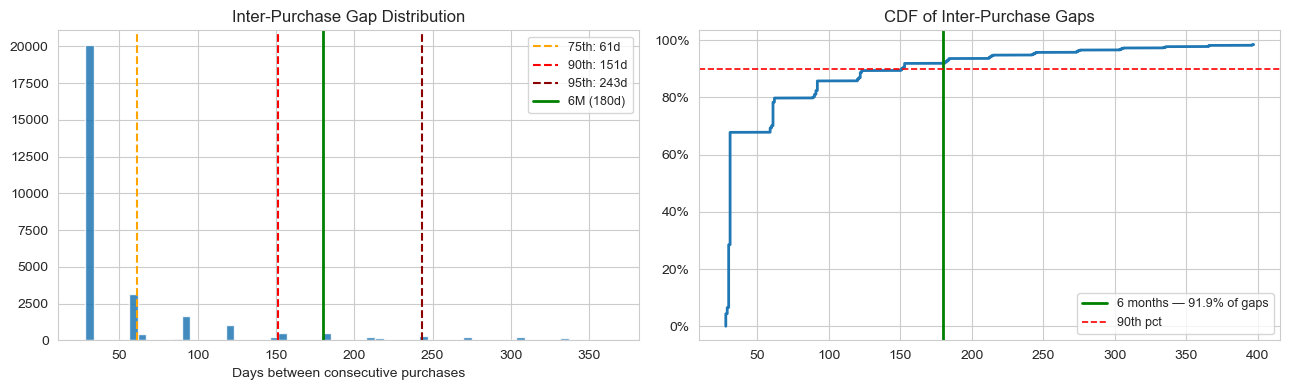

Inter-purchase gap percentiles:
  50th: 31 days (1.0 months)
  75th: 61 days (2.0 months)
  90th: 151 days (5.0 months)
  95th: 243 days (8.1 months)
  99th: 487 days (16.2 months)

91.9% of gaps fall within 180 days


In [8]:
# Validate the 6-month window with inter-purchase gap analysis
gaps = []
for _, grp in obs_tkt.groupby('custnumber'):
    months = sorted(grp['salesmonth'].unique())
    for i in range(len(months) - 1):
        gaps.append((months[i + 1] - months[i]).days)

gaps = pd.Series(gaps)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gaps[gaps <= 365], bins=60, edgecolor='white', alpha=0.85)
for pct, label, color in [(0.75, '75th', 'orange'), (0.90, '90th', 'red'), (0.95, '95th', 'darkred')]:
    v = gaps.quantile(pct)
    axes[0].axvline(v, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {v:.0f}d')
axes[0].axvline(180, color='green', linewidth=2, label=f'6M (180d)')
axes[0].set_title('Inter-Purchase Gap Distribution')
axes[0].set_xlabel('Days between consecutive purchases')
axes[0].legend(fontsize=9)

sg = np.sort(gaps); cdf = np.arange(1, len(sg) + 1) / len(sg)
axes[1].plot(sg[sg <= 400], cdf[sg <= 400], linewidth=2)
axes[1].axvline(180, color='green', linewidth=2,
                label=f'6 months — {(gaps<=180).mean()*100:.1f}% of gaps')
axes[1].axhline(0.90, color='red', linestyle='--', linewidth=1.2, label='90th pct')
axes[1].set_title('CDF of Inter-Purchase Gaps')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Inter-purchase gap percentiles:')
for p in [50, 75, 90, 95, 99]:
    v = gaps.quantile(p/100)
    print(f'  {p}th: {v:.0f} days ({v/30:.1f} months)')
print(f'\n{(gaps<=180).mean()*100:.1f}% of gaps fall within 180 days')


## 5. EDA

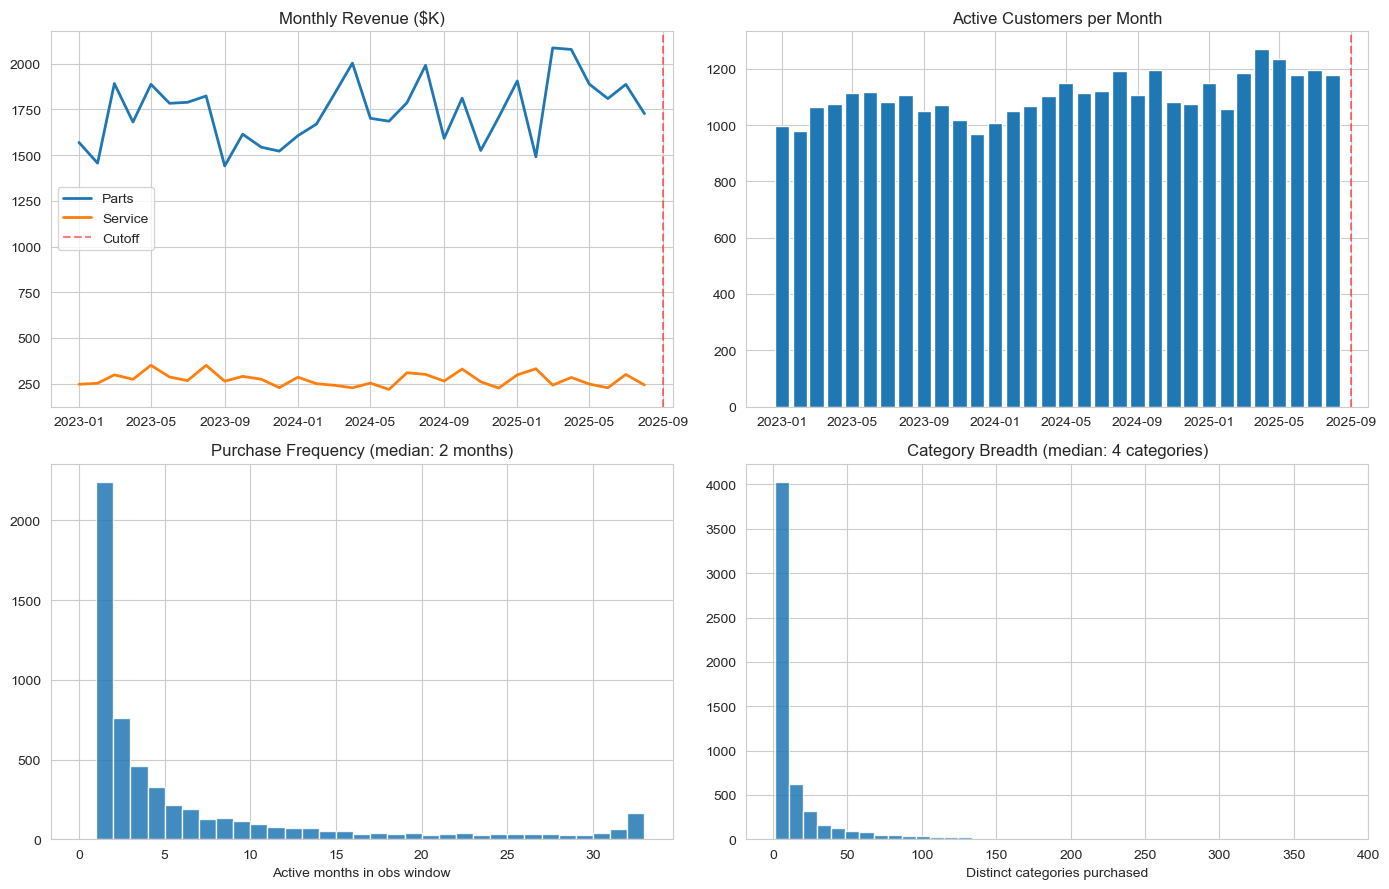

Parts revenue (obs) : $  55,767,849
Service revenue     : $   8,731,608
Parts + Service     : 1,985 (34.7%)
Parts only          : 3,734 (65.3%)
Top 10% revenue share: 87.6%


In [9]:
svc_custs = set(obs_svc['custnumber'])
with_svc   = len(obs_active & svc_custs)
parts_only = len(obs_active - svc_custs)

monthly_rev = obs_tkt.groupby('salesmonth')['sales'].sum().reset_index(name='parts')
monthly_svc = obs_svc.groupby('salesmonth')['sales'].sum().reset_index(name='service')
monthly     = monthly_rev.merge(monthly_svc, on='salesmonth', how='left').fillna(0)
monthly_act = obs_tkt.groupby('salesmonth')['custnumber'].nunique().reset_index(name='active')
freq_dist   = obs_tkt.groupby('custnumber')['salesmonth'].nunique()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(monthly['salesmonth'], monthly['parts']/1000, label='Parts', linewidth=2)
axes[0,0].plot(monthly['salesmonth'], monthly['service']/1000, label='Service', linewidth=2)
axes[0,0].axvline(CUTOFF, color='red', linestyle='--', alpha=0.5, label='Cutoff')
axes[0,0].set_title('Monthly Revenue ($K)'); axes[0,0].legend()

axes[0,1].bar(monthly_act['salesmonth'], monthly_act['active'], width=25, edgecolor='white')
axes[0,1].axvline(CUTOFF, color='red', linestyle='--', alpha=0.5)
axes[0,1].set_title('Active Customers per Month')

axes[1,0].hist(freq_dist, bins=range(0, freq_dist.max()+2), edgecolor='white', alpha=0.85)
axes[1,0].set_title(f'Purchase Frequency (median: {freq_dist.median():.0f} months)')
axes[1,0].set_xlabel('Active months in obs window')

n_cats = obs_cat.groupby('custnumber')['category'].nunique()
axes[1,1].hist(n_cats, bins=40, edgecolor='white', alpha=0.85)
axes[1,1].set_title(f'Category Breadth (median: {n_cats.median():.0f} categories)')
axes[1,1].set_xlabel('Distinct categories purchased')

plt.tight_layout(); plt.show()

print(f'Parts revenue (obs) : ${obs_tkt["sales"].sum():>12,.0f}')
print(f'Service revenue     : ${obs_svc["sales"].sum():>12,.0f}')
print(f'Parts + Service     : {with_svc:,} ({with_svc/len(obs_active)*100:.1f}%)')
print(f'Parts only          : {parts_only:,} ({parts_only/len(obs_active)*100:.1f}%)')

spend = obs_tkt.groupby('custnumber')['sales'].sum()
print(f'Top 10% revenue share: {spend.nlargest(int(len(spend)*0.1)).sum()/spend.sum()*100:.1f}%')


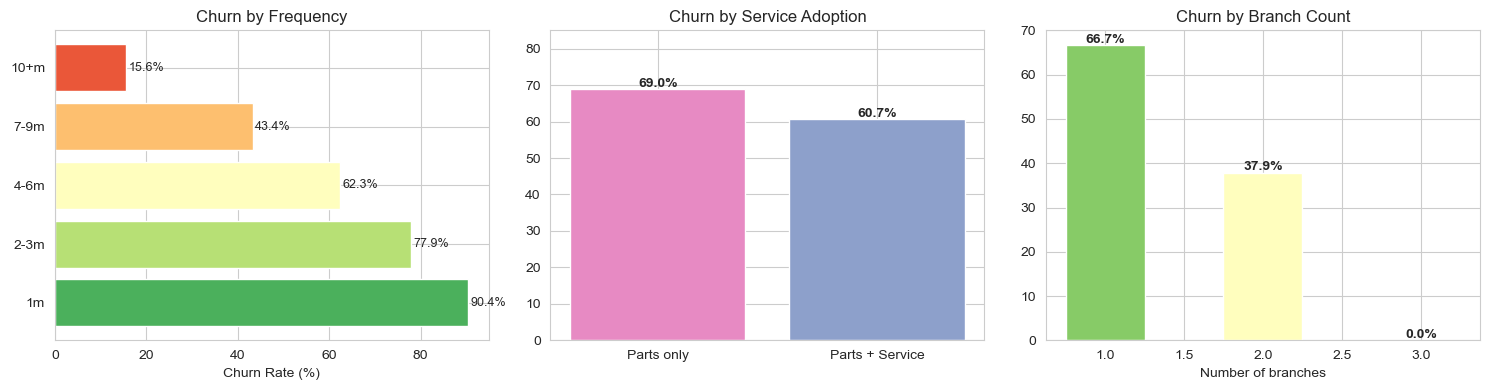

In [10]:
# Churn rates by key segments
lf = label_df.merge(obs_tkt.groupby('custnumber')['salesmonth'].nunique().reset_index(name='freq'), on='custnumber')
lf['has_svc'] = lf['custnumber'].isin(svc_custs)
lf['freq_bucket'] = pd.cut(lf['freq'], bins=[0,1,3,6,9,99],
                            labels=['1m','2-3m','4-6m','7-9m','10+m'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fc = lf.groupby('freq_bucket', observed=True)['churned'].agg(['mean','count']).reset_index()
axes[0].barh(fc['freq_bucket'], fc['mean']*100, color=sns.color_palette('RdYlGn_r', len(fc)))
for i, (_, row) in enumerate(fc.iterrows()):
    axes[0].text(row['mean']*100+0.5, i, f'{row["mean"]*100:.1f}%', va='center', fontsize=9)
axes[0].set_title('Churn by Frequency'); axes[0].set_xlabel('Churn Rate (%)')

sc = lf.groupby('has_svc')['churned'].mean()
axes[1].bar(['Parts only', 'Parts + Service'], sc.values*100,
            color=[sns.color_palette('Set2')[3], sns.color_palette('Set2')[2]])
for i, v in enumerate(sc.values*100):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn by Service Adoption'); axes[1].set_ylim(0, 85)

nloc = lf.merge(obs_tkt.groupby('custnumber')['location'].nunique().reset_index(name='nloc'), on='custnumber')
nc = nloc.groupby('nloc')['churned'].agg(['mean','count']).reset_index()
axes[2].bar(nc['nloc'], nc['mean']*100, color=sns.color_palette('RdYlGn_r', len(nc)), width=0.5)
for _, row in nc.iterrows():
    axes[2].text(row['nloc'], row['mean']*100+0.5, f'{row["mean"]*100:.1f}%', ha='center', fontweight='bold')
axes[2].set_xlabel('Number of branches'); axes[2].set_title('Churn by Branch Count')

plt.tight_layout(); plt.show()


## 6. Feature Engineering

24 features across 6 blocks — all computed before the Sep 2025 cutoff.

| Block | n | Window |
|---|---|---|
| Lifetime | 7 | Full 32-month history |
| Recency | 1 | Days to cutoff |
| Recent behaviour | 5 | Last 6 months |
| Trajectory | 4 | Recent vs prior 6 months |
| Service | 4 | Full obs history |
| Location | 3 | Full obs history |


In [11]:
# Ticket-level aggregation from ticket file
tkt_obs = obs_tkt.copy()

tkt_agg = (tkt_obs.groupby(['custnumber', 'ticketnumber', 'salesmonth', 'location'])
           .agg(ticket_sales=('sales', 'sum'), items=('itemcount', 'sum'))
           .reset_index())

# Category-level aggregation for breadth features
cat_agg = (obs_cat.groupby(['custnumber', 'ticketnumber', 'salesmonth'])
           .agg(ticket_sales_cat=('sales', 'sum'), n_categories=('category', 'nunique'))
           .reset_index())

print(f'Ticket obs records   : {len(tkt_agg):,}')
print(f'Category obs records : {len(cat_agg):,}')
print(f'Obs customers        : {tkt_agg["custnumber"].nunique():,}')


Ticket obs records   : 182,211
Category obs records : 182,951
Obs customers        : 5,719


In [12]:
# 6.1 Lifetime features
lifetime = (tkt_agg.groupby('custnumber').agg(
    first_purchase     = ('salesmonth', 'min'),
    last_purchase      = ('salesmonth', 'max'),
    lifetime_frequency = ('salesmonth', 'nunique'),
    lifetime_spend     = ('ticket_sales', 'sum'),
    lifetime_n_tickets = ('ticketnumber', 'nunique'),
    total_items        = ('items', 'sum'),
    avg_items_per_tkt  = ('items', 'mean'),
).reset_index())

lifetime['recency_days']  = (CUTOFF - lifetime['last_purchase']).dt.days
lifetime['tenure_months'] = ((CUTOFF - lifetime['first_purchase']).dt.days / 30).round(1)

# Category breadth from category file
lifetime_cats = (obs_cat.groupby('custnumber')['category']
                 .nunique().reset_index(name='lifetime_n_categories'))
avg_cats_per_tkt = (cat_agg.groupby('custnumber')['n_categories']
                    .mean().reset_index(name='avg_categories_per_tkt'))

lifetime = lifetime.merge(lifetime_cats, on='custnumber', how='left')
lifetime = lifetime.merge(avg_cats_per_tkt, on='custnumber', how='left')
lifetime['lifetime_n_categories']  = lifetime['lifetime_n_categories'].fillna(0)
lifetime['avg_categories_per_tkt'] = lifetime['avg_categories_per_tkt'].fillna(0)

print(f'Lifetime features: {len(lifetime):,} customers')
print(f'  Median spend     : ${lifetime["lifetime_spend"].median():,.0f}')
print(f'  Median frequency : {lifetime["lifetime_frequency"].median():.0f} months')
print(f'  Median n_cats    : {lifetime["lifetime_n_categories"].median():.0f}')


Lifetime features: 5,719 customers
  Median spend     : $571
  Median frequency : 2 months
  Median n_cats    : 4


In [13]:
# 6.2 Recent behaviour (last 6 months)
recent_tkt = tkt_agg[tkt_agg['salesmonth'] >= RECENT_START]
recent_cat = cat_agg[cat_agg['salesmonth'] >= RECENT_START]

recent = (recent_tkt.groupby('custnumber').agg(
    recent_spend       = ('ticket_sales', 'sum'),
    recent_frequency   = ('salesmonth', 'nunique'),
    recent_n_tickets   = ('ticketnumber', 'nunique'),
    recent_total_items = ('items', 'sum'),
    recent_avg_basket  = ('ticket_sales', 'mean'),
).reset_index())

recent_cats = (recent_cat.groupby('custnumber')['n_categories']
               .mean().reset_index(name='recent_n_categories'))
recent = recent.merge(recent_cats, on='custnumber', how='left')

print(f'Recent features: {len(recent):,} customers')


Recent features: 2,965 customers


In [14]:
# 6.3 Trajectory (recent vs prior 6 months)
prior_tkt = tkt_agg[(tkt_agg['salesmonth'] >= PRIOR_START) &
                     (tkt_agg['salesmonth'] < RECENT_START)]

prior = (prior_tkt.groupby('custnumber').agg(
    prior_spend     = ('ticket_sales', 'sum'),
    prior_frequency = ('salesmonth', 'nunique'),
).reset_index())

traj = recent[['custnumber', 'recent_spend', 'recent_frequency']].merge(
    prior, on='custnumber', how='outer').fillna(0)
traj['spend_change_6m'] = np.where(
    traj['prior_spend'] > 0,
    (traj['recent_spend'] - traj['prior_spend']) / traj['prior_spend'], np.nan)
traj['freq_change_6m'] = np.where(
    traj['prior_frequency'] > 0,
    (traj['recent_frequency'] - traj['prior_frequency']) / traj['prior_frequency'], np.nan)
traj = traj[['custnumber', 'spend_change_6m', 'freq_change_6m']]

# Average inter-purchase interval
def avg_interval(grp):
    m = sorted(grp['salesmonth'].unique())
    return np.mean([(m[i+1]-m[i]).days for i in range(len(m)-1)]) if len(m) > 1 else np.nan

interval_df = tkt_agg.groupby('custnumber', group_keys=False).apply(avg_interval).reset_index()
interval_df.columns = ['custnumber', 'avg_interval_days']

# Coefficient of variation of monthly spend (steady vs sporadic buyer)
def spend_cv(grp):
    m = grp.groupby('salesmonth')['ticket_sales'].sum()
    return m.std() / m.mean() if m.mean() > 0 else np.nan

cv_df = tkt_agg.groupby('custnumber', group_keys=False).apply(spend_cv).reset_index()
cv_df.columns = ['custnumber', 'spend_cv']

print(f'Trajectory features: {len(traj):,} customers')


Trajectory features: 3,892 customers


In [18]:
# 6.4 Service features
svc_feat = (obs_svc.groupby('custnumber').agg(
    svc_tickets = ('ticketnumber', 'nunique'),
    svc_spend   = ('sales', 'sum'),
).reset_index())
svc_feat['has_service'] = 1

last_svc = obs_svc.groupby('custnumber')['salesmonth'].max().reset_index(name='last_svc')
last_svc['months_since_last_svc'] = ((CUTOFF - last_svc['last_svc']).dt.days / 30).round(1)
svc_feat = svc_feat.merge(last_svc[['custnumber', 'months_since_last_svc']], on='custnumber', how='left')

print(f'Service features: {len(svc_feat):,} customers with service history')


Service features: 2,100 customers with service history


In [19]:
# 6.5 Branch context features
branch_stats = (obs_tkt.groupby('location').agg(
    branch_n_customers = ('custnumber', 'nunique'),
    branch_total_rev   = ('sales', 'sum'),
).reset_index().rename(columns={'location': 'primary_branch'}))

branch_stats['branch_avg_rev_per_cust'] = (
    branch_stats['branch_total_rev'] / branch_stats['branch_n_customers'])

svc_by_branch = (obs_tkt.merge(
    obs_svc[['custnumber']].drop_duplicates().assign(has_svc=1),
    on='custnumber', how='left')
    .groupby('location')['has_svc']
    .apply(lambda x: x.fillna(0).mean())
    .reset_index()
    .rename(columns={'location': 'primary_branch', 'has_svc': 'branch_svc_penetration'}))

branch_stats = branch_stats.merge(svc_by_branch, on='primary_branch', how='left')

print('Branch context features:')
print(branch_stats[['primary_branch', 'branch_n_customers', 'branch_avg_rev_per_cust',
                     'branch_svc_penetration']].round(3).to_string(index=False))


Branch context features:
primary_branch  branch_n_customers  branch_avg_rev_per_cust  branch_svc_penetration
       LOC_001                1043                 7957.898                   0.938
       LOC_002                2903                 7822.602                   0.292
       LOC_003                1888                13113.743                   0.088


In [20]:
# 6.6 Customer type (binary)
cust_type = pd.DataFrame({'custnumber': sorted(obs_active)})
cust_type['customer_type'] = cust_type['custnumber'].apply(
    lambda c: 'Parts + Service' if c in svc_custs else 'Parts only')

print('Customer type:')
print(cust_type['customer_type'].value_counts().to_string())


Customer type:
customer_type
Parts only         3734
Parts + Service    1985


In [21]:
# 6.7 Merge feature matrix
feat_df = (lifetime
           .merge(recent,       on='custnumber', how='left')
           .merge(traj,         on='custnumber', how='left')
           .merge(interval_df,  on='custnumber', how='left')
           .merge(cv_df,        on='custnumber', how='left')
           .merge(svc_feat,     on='custnumber', how='left')
           .merge(n_locs,       on='custnumber', how='left')
           .merge(pct_primary,  on='custnumber', how='left')
           .merge(cust_branch,  on='custnumber', how='left')
           .merge(branch_stats, on='primary_branch', how='left')
           .merge(cust_type,    on='custnumber', how='left')
           .merge(label_df,     on='custnumber', how='inner'))

# Fill defaults for customers with no activity in sub-windows
for c in ['recent_spend', 'recent_frequency', 'recent_n_tickets',
          'recent_total_items', 'recent_avg_basket', 'recent_n_categories']:
    feat_df[c] = feat_df[c].fillna(0)

for c in ['svc_tickets', 'svc_spend', 'has_service']:
    feat_df[c] = feat_df[c].fillna(0)

feat_df['months_since_last_svc'] = feat_df['months_since_last_svc'].fillna(99)
feat_df['pct_spend_primary']     = feat_df['pct_spend_primary'].fillna(1.0)
feat_df['spend_cv']              = feat_df['spend_cv'].fillna(feat_df['spend_cv'].median())
feat_df = feat_df.drop(columns=['first_purchase', 'last_purchase']).reset_index(drop=True)

FEATURE_COLS = [
    # Lifetime
    'tenure_months', 'lifetime_spend', 'lifetime_frequency', 'lifetime_n_tickets',
    'total_items', 'avg_items_per_tkt', 'lifetime_n_categories', 'avg_categories_per_tkt',
    # Recency
    'recency_days',
    # Recent behaviour
    'recent_spend', 'recent_frequency', 'recent_n_tickets',
    'recent_total_items', 'recent_avg_basket', 'recent_n_categories',
    # Trajectory
    'spend_change_6m', 'freq_change_6m', 'avg_interval_days', 'spend_cv',
    # Service
    'has_service', 'svc_tickets', 'svc_spend', 'months_since_last_svc',
    # Location
    'n_locations', 'pct_spend_primary',
    # Branch context
    'branch_avg_rev_per_cust', 'branch_svc_penetration',
]

print(f'Feature matrix: {feat_df.shape[0]:,} customers x {len(FEATURE_COLS)} features')
print(f'Churn rate    : {feat_df["churned"].mean()*100:.1f}%')
nulls = feat_df[FEATURE_COLS].isnull().sum()
if nulls.sum() > 0:
    print('Nulls remaining:', nulls[nulls > 0].to_dict())
else:
    print('No nulls in feature matrix.')


Feature matrix: 5,719 customers x 27 features
Churn rate    : 66.1%
Nulls remaining: {'spend_change_6m': 3053, 'freq_change_6m': 3053, 'avg_interval_days': 2244}


## 7. Modeling

In [22]:
X = feat_df[FEATURE_COLS]
y = feat_df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Churn rate  — train: {y_train.mean()*100:.1f}%  test: {y_test.mean()*100:.1f}%')


Train: 4,575 | Test: 1,144
Churn rate  — train: 66.1%  test: 66.1%


In [23]:
# Logistic Regression
lr_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print(f'Logistic Regression  AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}  PR-AUC: {average_precision_score(y_test, y_prob_lr):.4f}')


Logistic Regression  AUC-ROC: 0.8534  PR-AUC: 0.9003


In [24]:
# XGBoost
imp = SimpleImputer(strategy='median')
X_tr_imp = imp.fit_transform(X_train)
X_te_imp  = imp.transform(X_test)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr', random_state=42, verbosity=0)
xgb.fit(X_tr_imp, y_train)
y_prob_gb = xgb.predict_proba(X_te_imp)[:, 1]

print(f'XGBoost              AUC-ROC: {roc_auc_score(y_test, y_prob_gb):.4f}  PR-AUC: {average_precision_score(y_test, y_prob_gb):.4f}')


XGBoost              AUC-ROC: 0.8482  PR-AUC: 0.8997


     Metric     LR    XGB
    AUC-ROC 0.8534 0.8482
     PR-AUC 0.9003 0.8997
Brier Score 0.1501 0.1482
   Log Loss 0.4656 0.4598


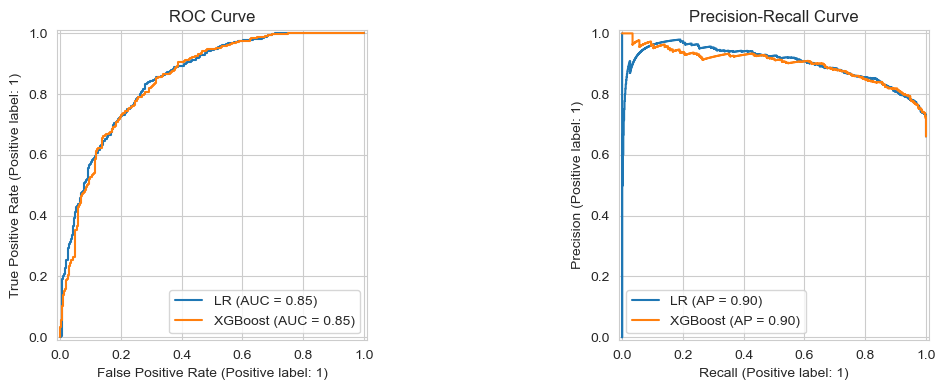

In [25]:
# Model comparison
lr_prauc = average_precision_score(y_test, y_prob_lr)
gb_prauc = average_precision_score(y_test, y_prob_gb)
lr_auc   = roc_auc_score(y_test, y_prob_lr)
gb_auc   = roc_auc_score(y_test, y_prob_gb)

metrics = pd.DataFrame({
    'Metric': ['AUC-ROC', 'PR-AUC', 'Brier Score', 'Log Loss'],
    'LR':  [lr_auc, lr_prauc, brier_score_loss(y_test, y_prob_lr), log_loss(y_test, y_prob_lr)],
    'XGB': [gb_auc, gb_prauc, brier_score_loss(y_test, y_prob_gb), log_loss(y_test, y_prob_gb)],
})
print(metrics.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='LR', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_gb, name='XGBoost', ax=axes[0])
axes[0].set_title('ROC Curve')

from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, name='LR', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_prob_gb, name='XGBoost', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout(); plt.show()


In [26]:
# Champion: XGBoost selected on business rationale (non-linear interactions,
# TreeExplainer compatibility) despite marginal PR-AUC difference.
# To use auto-selection instead: champion_is_xgb = (gb_prauc >= lr_prauc - 0.02)

champion_is_xgb = True
champion_name   = 'XGBoost'

X_all_imp = imp.transform(feat_df[FEATURE_COLS])
feat_df['churn_score'] = xgb.predict_proba(X_all_imp)[:, 1]
feat_df['risk_tier'] = feat_df['churn_score'].apply(
    lambda s: 'Low Risk' if s < 0.30 else ('Medium Risk' if s < 0.60 else 'High Risk'))

print(f'Champion: {champion_name}')
print(f'Score range: {feat_df["churn_score"].min():.4f} – {feat_df["churn_score"].max():.4f}')
print(f'\nRisk tier distribution:')
print(feat_df['risk_tier'].value_counts().to_string())


Champion: XGBoost
Score range: 0.0015 – 0.9643

Risk tier distribution:
risk_tier
High Risk      3467
Low Risk       1386
Medium Risk     866


## 8. Calibration

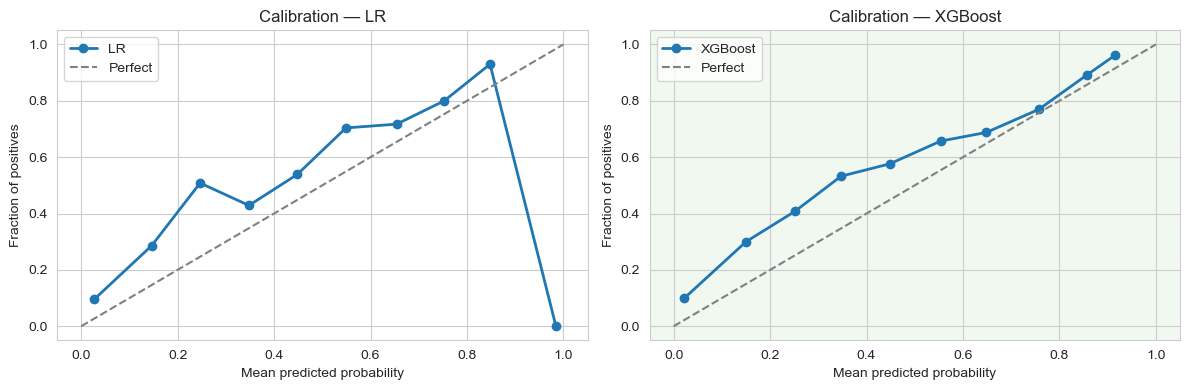

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, probs, name in [(axes[0], y_prob_lr, 'LR'), (axes[1], y_prob_gb, 'XGBoost')]:
    fc, mp = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mp, fc, marker='o', linewidth=2, label=name)
    ax.plot([0,1], [0,1], '--', color='gray', label='Perfect')
    ax.set_title(f'Calibration — {name}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend()
    if name == champion_name:
        ax.set_facecolor('#f0f8f0')
plt.tight_layout(); plt.show()


## 9. SHAP Explainability

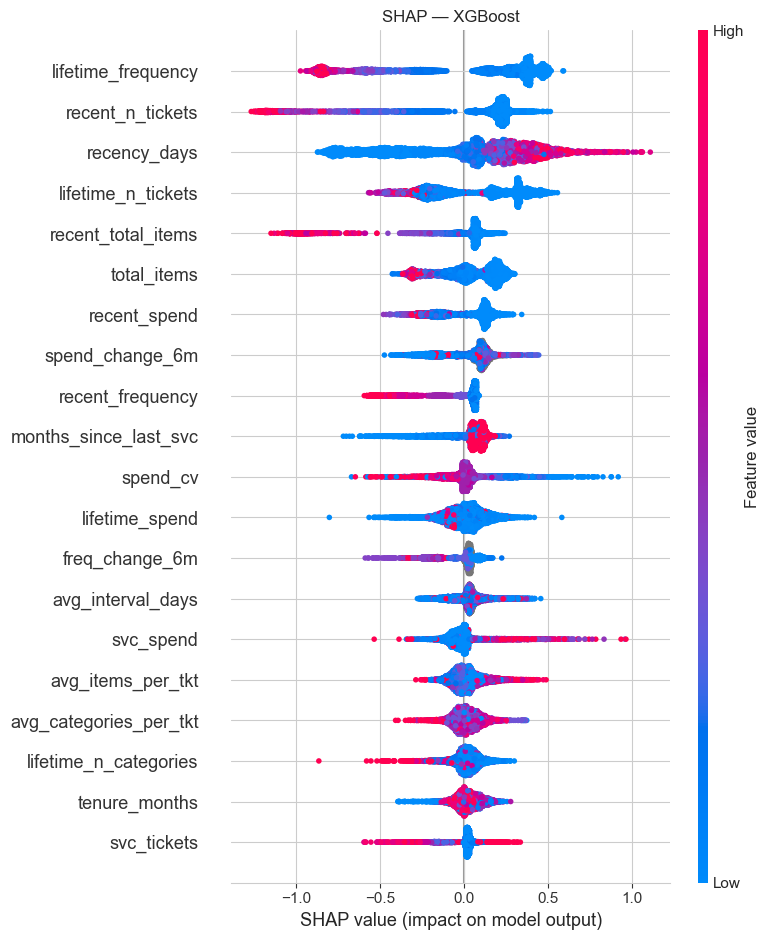

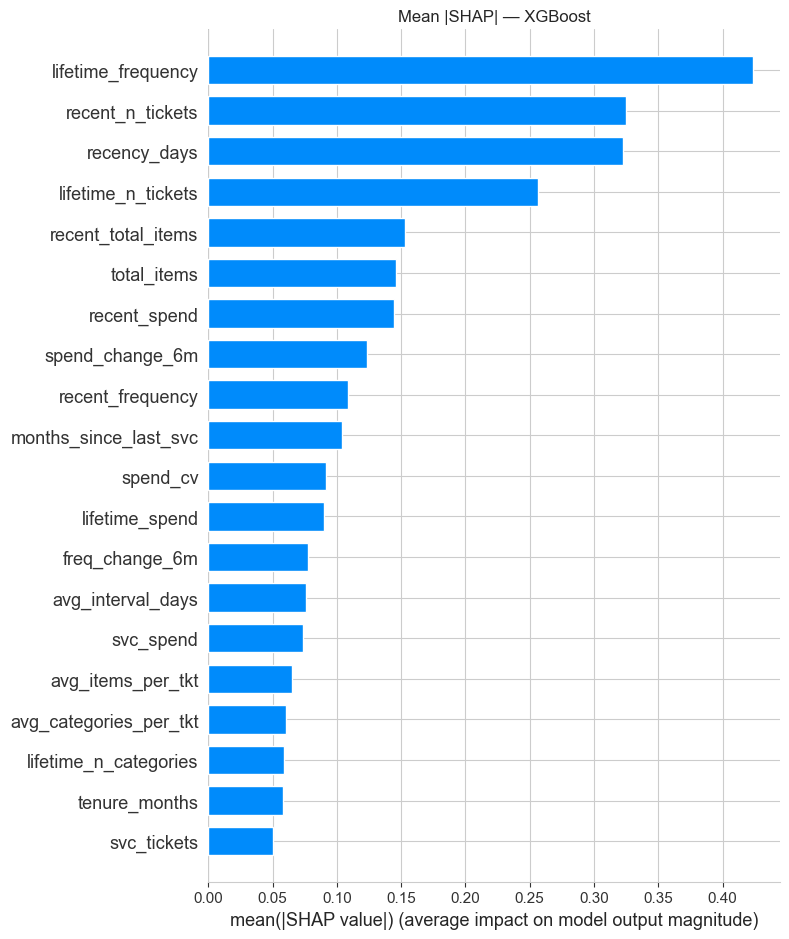

In [28]:
explainer   = shap.TreeExplainer(xgb)
shap_values = np.array(explainer.shap_values(X_all_imp))

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, feat_df[FEATURE_COLS],
                  feature_names=FEATURE_COLS, plot_type='dot', show=False)
plt.title(f'SHAP — {champion_name}')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, feat_df[FEATURE_COLS],
                  feature_names=FEATURE_COLS, plot_type='bar', show=False)
plt.title(f'Mean |SHAP| — {champion_name}')
plt.tight_layout(); plt.show()


In [29]:
# Per-customer reason codes
def fmt(feat, val):
    if pd.isna(val):              return 'N/A'
    if 'spend' in feat or 'basket' in feat: return f'${val:,.0f}'
    if 'change' in feat:          return f'{val*100:+.0f}%'
    if feat in ['recency_days', 'avg_interval_days']: return f'{val:.0f} days'
    if 'months' in feat:          return f'{val:.0f} mo'
    if feat == 'has_service':     return 'yes' if val == 1 else 'no'
    if feat == 'pct_spend_primary': return f'{val*100:.0f}%'
    if feat == 'branch_svc_penetration': return f'{val*100:.1f}%'
    try:
        if val == int(val): return f'{int(val)}'
    except (ValueError, OverflowError):
        pass
    return f'{val:.2f}'

sv_df = pd.DataFrame(shap_values, columns=FEATURE_COLS)

def top_reasons(i, n=3):
    av = sv_df.iloc[i][FEATURE_COLS].abs().sort_values(ascending=False).head(n)
    out = []
    for feat in av.index:
        direction = 'risk_up' if sv_df.iloc[i][feat] > 0 else 'risk_down'
        out.append(f'{feat}={fmt(feat, feat_df.iloc[i][feat])} ({direction})')
    while len(out) < n:
        out.append('')
    return out

feat_df['reason_1'] = [top_reasons(i)[0] for i in range(len(feat_df))]
feat_df['reason_2'] = [top_reasons(i)[1] for i in range(len(feat_df))]
feat_df['reason_3'] = [top_reasons(i)[2] for i in range(len(feat_df))]

print('Sample reason codes (top 5 by churn score):')
print(feat_df.nlargest(5, 'churn_score')[
    ['custnumber', 'primary_branch', 'customer_type', 'churn_score', 'reason_1', 'reason_2']
].to_string(index=False))


Sample reason codes (top 5 by churn score):
custnumber primary_branch   customer_type  churn_score                        reason_1                        reason_2
CUST_02863        LOC_002      Parts only     0.964298           spend_cv=$0 (risk_up) recency_days=549 days (risk_up)
CUST_02764        LOC_002      Parts only     0.963108 recency_days=640 days (risk_up)    recent_n_tickets=0 (risk_up)
CUST_04198        LOC_003      Parts only     0.960484 recency_days=609 days (risk_up)    recent_n_tickets=0 (risk_up)
CUST_05944        LOC_003      Parts only     0.960119 recency_days=915 days (risk_up)           spend_cv=$0 (risk_up)
CUST_01961        LOC_002 Parts + Service     0.955685 recency_days=823 days (risk_up)    recent_n_tickets=0 (risk_up)


## 10. Survival Analysis

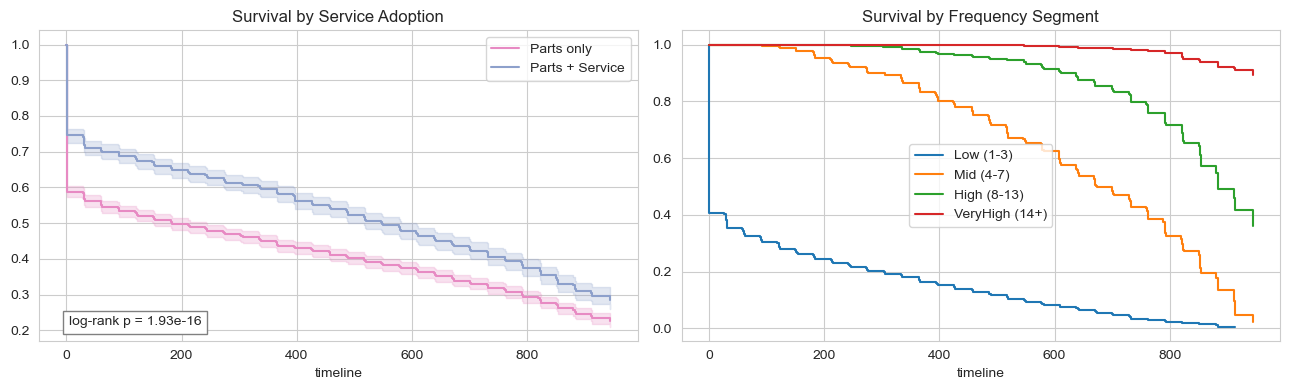

Cox PH C-index: 0.9670
                           coef  exp(coef)       p
covariate                                         
tenure_months           -0.1840     0.8319  0.0000
lifetime_spend          -0.0000     1.0000  0.7227
lifetime_frequency      -0.0656     0.9365  0.0000
lifetime_n_tickets      -0.0002     0.9998  0.2634
total_items             -0.0000     1.0000  0.5015
avg_items_per_tkt        0.0195     1.0196  0.5195
lifetime_n_categories   -0.0013     0.9987  0.3583
avg_categories_per_tkt   0.0196     1.0198  0.5492
recency_days             0.0070     1.0070  0.0000
recent_spend            -0.0000     1.0000  0.6078
recent_frequency        -0.2353     0.7903  0.0000
recent_n_tickets        -0.0012     0.9988  0.1769
recent_total_items      -0.0003     0.9997  0.3537
recent_avg_basket       -0.0001     0.9999  0.3133
recent_n_categories     -0.0281     0.9723  0.4212
spend_change_6m         -0.0012     0.9988  0.6875
freq_change_6m          -0.1078     0.8978  0.0255
avg_inte

In [30]:
feat_df['duration'] = ((feat_df['tenure_months'] - feat_df['recency_days'] / 30) * 30).clip(lower=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
kmf = KaplanMeierFitter()

# By service adoption
for svc, label, color in [(0, 'Parts only', sns.color_palette('Set2')[3]),
                           (1, 'Parts + Service', sns.color_palette('Set2')[2])]:
    g = feat_df[feat_df['has_service'] == svc]
    kmf.fit(g['duration'], g['churned'], label=label)
    kmf.plot_survival_function(ax=axes[0], color=color, ci_show=True)

g0 = feat_df[feat_df['has_service'] == 0]
g1 = feat_df[feat_df['has_service'] == 1]
lr_test = logrank_test(g0['duration'], g1['duration'], g0['churned'], g1['churned'])
axes[0].text(0.05, 0.05, f'log-rank p = {lr_test.p_value:.2e}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(facecolor='white', edgecolor='gray'))
axes[0].set_title('Survival by Service Adoption')

# By frequency segment
feat_df['freq_seg'] = pd.cut(feat_df['lifetime_frequency'],
    bins=[0, 3, 7, 13, 100], labels=['Low (1-3)', 'Mid (4-7)', 'High (8-13)', 'VeryHigh (14+)'])
kmf2 = KaplanMeierFitter()
for seg in feat_df['freq_seg'].cat.categories:
    g = feat_df[feat_df['freq_seg'] == seg]
    kmf2.fit(g['duration'], g['churned'], label=str(seg))
    kmf2.plot_survival_function(ax=axes[1], ci_show=False)
axes[1].set_title('Survival by Frequency Segment')

plt.tight_layout(); plt.show()

# Cox PH
cox_data = feat_df[FEATURE_COLS + ['duration', 'churned']].dropna()
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col='duration', event_col='churned')
print(f'Cox PH C-index: {cph.concordance_index_:.4f}')
print(cph.summary[['coef', 'exp(coef)', 'p']].round(4).to_string())


## 11. Temporal Backtest

In [31]:
first_purch = obs_tkt.groupby('custnumber')['salesmonth'].min()
feat_df['first_year'] = feat_df['custnumber'].map(first_purch).dt.year

tr_m = feat_df['first_year'] < 2024
te_m = feat_df['first_year'] >= 2024

imp_t = SimpleImputer(strategy='median')
X_tr_t = imp_t.fit_transform(feat_df.loc[tr_m, FEATURE_COLS])
X_te_t = imp_t.transform(feat_df.loc[te_m, FEATURE_COLS])
y_tr_t = feat_df.loc[tr_m, 'churned']
y_te_t = feat_df.loc[te_m, 'churned']

neg_t, pos_t = (y_tr_t == 0).sum(), (y_tr_t == 1).sum()
xgb_t = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                       subsample=0.8, scale_pos_weight=neg_t/pos_t,
                       eval_metric='aucpr', random_state=42, verbosity=0)
xgb_t.fit(X_tr_t, y_tr_t)
p_tmp = xgb_t.predict_proba(X_te_t)[:, 1]

print(f'Random split    AUC={roc_auc_score(y_test, y_prob_gb):.4f}  PR={average_precision_score(y_test, y_prob_gb):.4f}')
print(f'Temporal split  AUC={roc_auc_score(y_te_t, p_tmp):.4f}  PR={average_precision_score(y_te_t, p_tmp):.4f}')
print(f'Train: {tr_m.sum():,} (pre-2024)  |  Test: {te_m.sum():,} (2024+)')


Random split    AUC=0.8482  PR=0.8997
Temporal split  AUC=0.7555  PR=0.8975
Train: 3,350 (pre-2024)  |  Test: 2,369 (2024+)


## 12. Branch-Level Driver Analysis

Branch summary:

LOC_001  (1,004 customers)
  Churn rate           : 58.7%
  Avg score            : 0.498
  High risk            : 499
  Service penetration  : 94.5%
  Parts only churn     : 65.5%
  Parts + Service churn: 58.3%

LOC_002  (2,861 customers)
  Churn rate           : 67.4%
  Avg score            : 0.606
  High risk            : 1,798
  Service penetration  : 35.8%
  Parts only churn     : 69.7%
  Parts + Service churn: 63.2%

LOC_003  (1,854 customers)
  Churn rate           : 68.1%
  Avg score            : 0.610
  High risk            : 1,170
  Service penetration  : 0.6%
  Parts only churn     : 68.3%
  Parts + Service churn: 33.3%


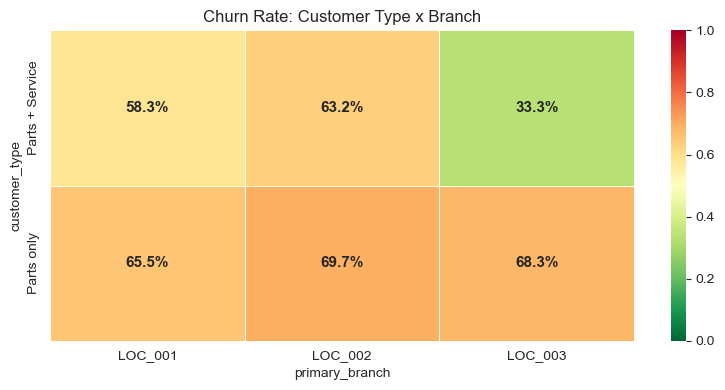

In [32]:
print('Branch summary:')
for branch in sorted(feat_df['primary_branch'].dropna().unique()):
    b = feat_df[feat_df['primary_branch'] == branch]
    print(f'\n{branch}  ({len(b):,} customers)')
    print(f'  Churn rate           : {b["churned"].mean()*100:.1f}%')
    print(f'  Avg score            : {b["churn_score"].mean():.3f}')
    print(f'  High risk            : {(b["risk_tier"]=="High Risk").sum():,}')
    print(f'  Service penetration  : {b["has_service"].mean()*100:.1f}%')
    print(f'  Parts only churn     : {b[b["customer_type"]=="Parts only"]["churned"].mean()*100:.1f}%')
    print(f'  Parts + Service churn: {b[b["customer_type"]=="Parts + Service"]["churned"].mean()*100:.1f}%')

# Heatmap
ct_branch = feat_df.groupby(['primary_branch', 'customer_type'])['churned'].mean().reset_index()
pivot = ct_branch.pivot(index='customer_type', columns='primary_branch', values='churned')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r', linewidths=0.5,
            ax=ax, vmin=0, vmax=1, annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Churn Rate: Customer Type x Branch')
plt.tight_layout(); plt.show()


In [33]:
# Top SHAP drivers per branch
sv_branch = pd.DataFrame(shap_values, columns=FEATURE_COLS)
sv_branch['primary_branch'] = feat_df['primary_branch'].values

print('Top 5 SHAP drivers by branch:')
for branch in sorted(sv_branch['primary_branch'].dropna().unique()):
    top5 = (sv_branch[sv_branch['primary_branch'] == branch][FEATURE_COLS]
            .abs().mean().sort_values(ascending=False).head(5))
    print(f'\n{branch}:')
    for f, v in top5.items():
        print(f'  {f:<35}: {v:.4f}')


Top 5 SHAP drivers by branch:

LOC_001:
  lifetime_frequency                 : 0.4366
  recent_n_tickets                   : 0.3392
  recency_days                       : 0.3195
  lifetime_n_tickets                 : 0.2284
  recent_total_items                 : 0.1739

LOC_002:
  lifetime_frequency                 : 0.4183
  recent_n_tickets                   : 0.3230
  recency_days                       : 0.3216
  lifetime_n_tickets                 : 0.2604
  recent_total_items                 : 0.1511

LOC_003:
  lifetime_frequency                 : 0.4245
  recency_days                       : 0.3260
  recent_n_tickets                   : 0.3207
  lifetime_n_tickets                 : 0.2656
  recent_spend                       : 0.1463


## 13. Conditional Probability Tables

P(Churn | frequency):
                  mean  count
freq_bucket                  
Low (1-3m)       0.860   3465
Mid (4-7m)       0.602    865
High (8-13m)     0.363    559
VeryHigh (14+m)  0.090    830

P(Churn | customer type):
                  mean  count
customer_type                
Parts + Service  0.607   1985
Parts only       0.690   3734


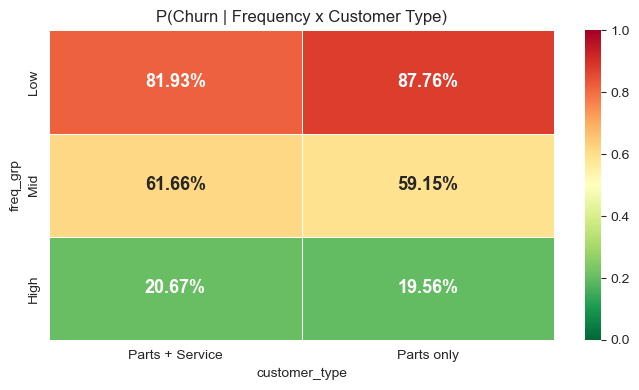


P(Churn | n_locations):
              mean  count
n_locations              
1            0.667   5614
2            0.379     95
3            0.000     10


In [34]:
feat_df['freq_bucket'] = pd.cut(feat_df['lifetime_frequency'],
    bins=[0, 3, 7, 13, 100],
    labels=['Low (1-3m)', 'Mid (4-7m)', 'High (8-13m)', 'VeryHigh (14+m)'])

print('P(Churn | frequency):')
print(feat_df.groupby('freq_bucket', observed=True)['churned']
      .agg(['mean', 'count']).round(3).to_string())

print('\nP(Churn | customer type):')
print(feat_df.groupby('customer_type')['churned']
      .agg(['mean', 'count']).round(3).to_string())

# Joint: frequency x service
feat_df['freq_grp'] = pd.cut(feat_df['lifetime_frequency'],
    bins=[0, 3, 7, 100], labels=['Low', 'Mid', 'High'])
joint = (feat_df.groupby(['freq_grp', 'customer_type'], observed=True)['churned']
         .mean().reset_index())
pivot_j = joint.pivot(index='freq_grp', columns='customer_type', values='churned')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_j, annot=True, fmt='.2%', cmap='RdYlGn_r', linewidths=0.5,
            ax=ax, vmin=0, vmax=1, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('P(Churn | Frequency x Customer Type)')
plt.tight_layout(); plt.show()

print('\nP(Churn | n_locations):')
print(feat_df.groupby('n_locations')['churned']
      .agg(['mean', 'count']).round(3).to_string())


## 14. Uplift Modeling (T-Learner)

In [35]:
feat_df['retained'] = 1 - feat_df['churned']
UPLIFT_FEATURES = [c for c in FEATURE_COLS
                   if c not in ('has_service', 'svc_tickets', 'svc_spend', 'months_since_last_svc')]

treated = feat_df[feat_df['has_service'] == 1]
control = feat_df[feat_df['has_service'] == 0]

imp_u = SimpleImputer(strategy='median')
X_t = imp_u.fit_transform(treated[UPLIFT_FEATURES])
X_c = imp_u.transform(control[UPLIFT_FEATURES])

model_t = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                         subsample=0.8, eval_metric='logloss', random_state=42, verbosity=0)
model_c = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                         subsample=0.8, eval_metric='logloss', random_state=42, verbosity=0)
model_t.fit(X_t, treated['retained'])
model_c.fit(X_c, control['retained'])

X_all_u = imp_u.transform(feat_df[UPLIFT_FEATURES])
feat_df['p_retain_treated'] = model_t.predict_proba(X_all_u)[:, 1]
feat_df['p_retain_control'] = model_c.predict_proba(X_all_u)[:, 1]
feat_df['uplift_score']     = feat_df['p_retain_treated'] - feat_df['p_retain_control']

# Targeting matrix
feat_df['targeting_segment'] = 'Do not contact'
feat_df.loc[(feat_df['churn_score'] >= 0.5) & (feat_df['uplift_score'] > 0),
            'targeting_segment'] = 'Priority outreach'
feat_df.loc[(feat_df['churn_score'] >= 0.5) & (feat_df['uplift_score'] <= 0),
            'targeting_segment'] = 'At risk - unlikely to respond'
feat_df.loc[(feat_df['churn_score'] < 0.5) & (feat_df['uplift_score'] > 0),
            'targeting_segment'] = 'Low risk - but receptive'

print('Targeting matrix:')
print(feat_df['targeting_segment'].value_counts().to_string())
print('\nBy branch:')
print(feat_df.groupby(['primary_branch', 'targeting_segment']).size()
      .unstack(fill_value=0).to_string())


Targeting matrix:
targeting_segment
Priority outreach                2649
At risk - unlikely to respond    1125
Do not contact                   1010
Low risk - but receptive          935

By branch:
targeting_segment  At risk - unlikely to respond  Do not contact  Low risk - but receptive  Priority outreach
primary_branch                                                                                               
LOC_001                                      231             226                       219                328
LOC_002                                      545             422                       497               1397
LOC_003                                      349             362                       219                924


In [36]:
def recommend_action(row):
    seg     = row['targeting_segment']
    has_svc = row['has_service']
    freq    = row['lifetime_frequency']
    recency = row['recency_days']
    spend_d = row['spend_change_6m']

    if seg == 'Do not contact':
        return 'Monitor only - no outreach'
    if seg == 'At risk - unlikely to respond':
        return 'Send win-back offer (low effort) - do not invest call time'
    if seg == 'Low risk - but receptive':
        return ('Introduce service department - relationship building call'
                if has_svc == 0 else 'Quarterly check-in call - maintain relationship')
    # Priority outreach branches
    if has_svc == 0 and freq <= 3:
        return 'Service conversion call - convert one-time buyer into service relationship'
    if has_svc == 0 and freq > 3:
        return 'Service conversion priority - regular buyer with no service anchor'
    if pd.notna(spend_d) and spend_d < -0.5:
        return 'Investigate spend drop - call to understand business situation'
    if recency > 90:
        return 'Reactivation call - extended silence, offer re-engagement incentive'
    return 'Priority outreach call - discuss recent activity and offer service'

feat_df['action_item'] = feat_df.apply(recommend_action, axis=1)

print('Action distribution:')
print(feat_df['action_item'].value_counts().to_string())


Action distribution:
action_item
Service conversion call - convert one-time buyer into service relationship    1741
Send win-back offer (low effort) - do not invest call time                    1125
Monitor only - no outreach                                                    1010
Introduce service department - relationship building call                      501
Reactivation call - extended silence, offer re-engagement incentive            456
Quarterly check-in call - maintain relationship                                434
Service conversion priority - regular buyer with no service anchor             207
Investigate spend drop - call to understand business situation                 180
Priority outreach call - discuss recent activity and offer service              65


## 15. Revenue at Risk

Revenue at Risk:
  Total RAR               : $     1,330,890
  High Risk RAR           : $       624,739
  Priority outreach RAR   : $       582,971

By branch:
primary_branch
LOC_001    $196,243
LOC_002    $532,992
LOC_003    $601,655


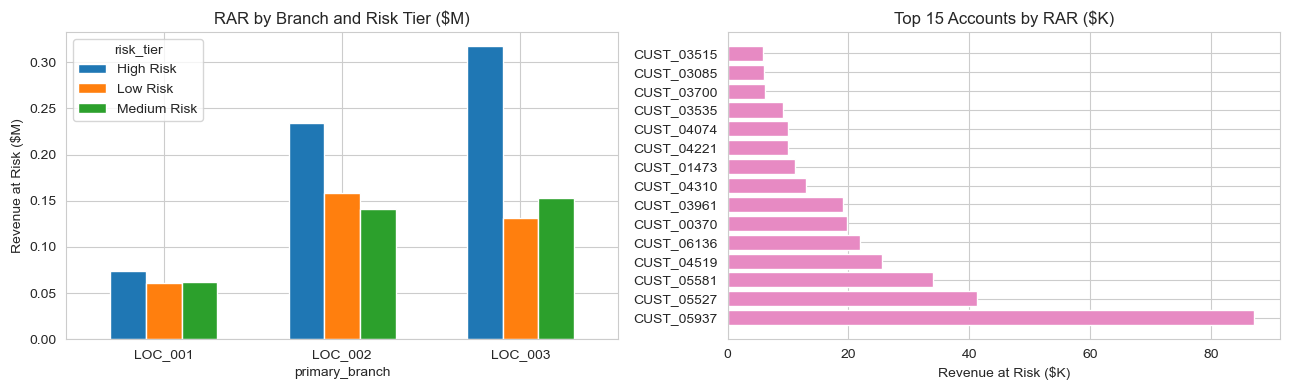

In [37]:
# RAR = annual spend (last 12 months) x churn probability
annual_spend = (tkt_pos[(tkt_pos['salesmonth'] >= ANNUAL_START) &
                         (tkt_pos['salesmonth'] < CUTOFF)]
                .groupby('custnumber')['sales'].sum()
                .reset_index(name='annual_spend_last12m'))

feat_df = feat_df.merge(annual_spend, on='custnumber', how='left')
feat_df['annual_spend_last12m'] = feat_df['annual_spend_last12m'].fillna(0)
feat_df['revenue_at_risk']      = feat_df['annual_spend_last12m'] * feat_df['churn_score']

print('Revenue at Risk:')
print(f'  Total RAR               : ${feat_df["revenue_at_risk"].sum():>14,.0f}')
print(f'  High Risk RAR           : ${feat_df[feat_df["risk_tier"]=="High Risk"]["revenue_at_risk"].sum():>14,.0f}')
print(f'  Priority outreach RAR   : ${feat_df[feat_df["targeting_segment"]=="Priority outreach"]["revenue_at_risk"].sum():>14,.0f}')
print(f'\nBy branch:')
print(feat_df.groupby('primary_branch')['revenue_at_risk']
      .sum().apply(lambda x: f'${x:,.0f}').to_string())

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

branch_rar = (feat_df.groupby(['primary_branch', 'risk_tier'], observed=True)['revenue_at_risk']
              .sum().reset_index())
pivot_rar = branch_rar.pivot(index='primary_branch', columns='risk_tier',
                              values='revenue_at_risk').fillna(0)
pivot_rar.div(1e6).plot(kind='bar', ax=axes[0], edgecolor='white', width=0.6)
axes[0].set_title('RAR by Branch and Risk Tier ($M)')
axes[0].set_ylabel('Revenue at Risk ($M)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

top_rar = feat_df.nlargest(15, 'revenue_at_risk')
axes[1].barh(top_rar['custnumber'], top_rar['revenue_at_risk'] / 1000,
             color=sns.color_palette('Set2')[3], edgecolor='white')
axes[1].set_title('Top 15 Accounts by RAR ($K)')
axes[1].set_xlabel('Revenue at Risk ($K)')

plt.tight_layout(); plt.show()


## 16. Export Call List

In [40]:
final = feat_df[[
    'custnumber', 'primary_branch', 'customer_type',
    'churn_score', 'risk_tier', 'uplift_score', 'targeting_segment',
    'action_item', 'p_retain_treated', 'p_retain_control',
    'recency_days', 'lifetime_frequency', 'lifetime_spend',
    'lifetime_n_categories', 'recent_spend', 'has_service',
    'annual_spend_last12m', 'revenue_at_risk',
    'churned', 'reason_1', 'reason_2', 'reason_3'
]].sort_values('churn_score', ascending=False).reset_index(drop=True)

final.to_csv('fleetpride_final_call_list_submission.csv', index=False, encoding='utf-8-sig')
print(f'Exported: fleetpride_final_call_list.csv  ({len(final):,} rows)')

print('\nTop 10 Priority Outreach accounts:')
print(final[final['targeting_segment'] == 'Priority outreach'][
    ['custnumber', 'primary_branch', 'customer_type',
     'churn_score', 'revenue_at_risk', 'action_item', 'reason_1']
].head(10).to_string(index=False))

print('\nBranch summary:')
print(final.groupby('primary_branch').agg(
    n=('custnumber', 'count'),
    churn_rate=('churned', 'mean'),
    avg_score=('churn_score', 'mean'),
    total_rar=('revenue_at_risk', 'sum')
).round(3).to_string())


Exported: fleetpride_final_call_list.csv  (5,719 rows)

Top 10 Priority Outreach accounts:
custnumber primary_branch customer_type  churn_score  revenue_at_risk                                                                action_item                        reason_1
CUST_02764        LOC_002    Parts only     0.963108         0.000000         Service conversion priority - regular buyer with no service anchor recency_days=640 days (risk_up)
CUST_04198        LOC_003    Parts only     0.960484         0.000000         Service conversion priority - regular buyer with no service anchor recency_days=609 days (risk_up)
CUST_05944        LOC_003    Parts only     0.960119         0.000000 Service conversion call - convert one-time buyer into service relationship recency_days=915 days (risk_up)
CUST_03297        LOC_002    Parts only     0.947345         0.000000 Service conversion call - convert one-time buyer into service relationship recency_days=943 days (risk_up)
CUST_02338        LOC_00

## 17. Validation

In [39]:
checks = []

# CUST_02421 — known loyal high-value account, should be Low Risk
c = feat_df[feat_df['custnumber'] == 'CUST_05527']
if len(c):
    row = c.iloc[0]
    passed = row['risk_tier'] == 'Low Risk' and row['churned'] == 0
    checks.append(('CUST_05527 (top spender, active every month) is Low Risk',
                   f'score={row["churn_score"]:.4f}  tier={row["risk_tier"]}  churned={row["churned"]}',
                   passed))

# Top 10 spenders should be predominantly low risk
top10 = feat_df.nlargest(10, 'lifetime_spend')
lr_pct = (top10['risk_tier'] == 'Low Risk').mean()
checks.append(('Top 10 spenders mostly Low Risk',
               f'{int(lr_pct*10)}/10 Low Risk  churn rate {top10["churned"].mean()*100:.0f}%',
               lr_pct >= 0.7))

# 1-month buyers should be predominantly High Risk
f1 = feat_df[feat_df['lifetime_frequency'] == 1]
hr_pct = (f1['risk_tier'] == 'High Risk').mean()
checks.append(('1-month buyers mostly High Risk',
               f'{hr_pct*100:.0f}% High Risk (n={len(f1):,})',
               hr_pct >= 0.7))

# Monotonicity checks
corr_r = feat_df['churn_score'].corr(feat_df['recency_days'])
corr_f = feat_df['churn_score'].corr(feat_df['lifetime_frequency'])
checks.append(('Score positively correlated with recency',
               f'r = {corr_r:.3f}', corr_r > 0.3))
checks.append(('Score negatively correlated with frequency',
               f'r = {corr_f:.3f}', corr_f < -0.3))

# Multi-location customers churn less
multi = feat_df[feat_df['n_locations'] > 1]
single = feat_df[feat_df['n_locations'] == 1]
checks.append(('Multi-location customers churn less',
               f'multi={multi["churned"].mean()*100:.1f}%  single={single["churned"].mean()*100:.1f}%',
               multi['churned'].mean() < single['churned'].mean()))

# Champion AUC
auc = roc_auc_score(y_test, y_prob_gb)
checks.append(('Champion AUC-ROC >= 0.80',
               f'{auc:.4f}', auc >= 0.80))

# No nulls in key call list columns
nulls = final[['churn_score', 'risk_tier', 'targeting_segment',
               'action_item', 'reason_1']].isnull().sum().sum()
checks.append(('No nulls in key call list columns',
               f'{nulls} nulls found', nulls == 0))

print('=== VALIDATION CHECKS ===\n')
for desc, detail, passed in checks:
    status = 'PASS' if passed else 'FAIL'
    print(f'[{status}]  {desc}')
    print(f'         {detail}\n')

n_pass = sum(c[2] for c in checks)
print(f'Result: {n_pass}/{len(checks)} checks passed')
print(f'Champion: {champion_name}  |  Universe: {len(feat_df):,}  |  Churn rate: {feat_df["churned"].mean()*100:.1f}%')


=== VALIDATION CHECKS ===

[PASS]  CUST_05527 (top spender, active every month) is Low Risk
         score=0.0107  tier=Low Risk  churned=0

[PASS]  Top 10 spenders mostly Low Risk
         10/10 Low Risk  churn rate 0%

[PASS]  1-month buyers mostly High Risk
         98% High Risk (n=2,244)

[PASS]  Score positively correlated with recency
         r = 0.636

[PASS]  Score negatively correlated with frequency
         r = -0.809

[PASS]  Multi-location customers churn less
         multi=34.3%  single=66.7%

[PASS]  Champion AUC-ROC >= 0.80
         0.8482

[PASS]  No nulls in key call list columns
         0 nulls found

Result: 8/8 checks passed
Champion: XGBoost  |  Universe: 5,719  |  Churn rate: 66.1%
